In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import time
import warnings
from IPython.display import clear_output, display

warnings.filterwarnings('ignore')

COLOR_PRIMARIO   = '#1A3C5E'
COLOR_SECUNDARIO = '#2E86AB'
COLOR_ACENTO     = '#F5A623'
COLOR_POSITIVO   = '#27AE60'
COLOR_NEGATIVO   = '#E74C3C'
COLOR_NEUTRO     = '#95A5A6'
FONDO            = '#F0F4F8'
COLORES_CAT      = ['#1A3C5E','#2E86AB','#F5A623','#27AE60','#E74C3C',
                    '#8E44AD','#16A085','#D35400','#2C3E50','#F39C12']

In [14]:
print("Cargando datos desde archivos .txt …")

facturas = pd.read_csv(
    '/content/facturas.txt', sep=';', header=None,
    names=['Fecha','Hora','Nombre_Cliente','Tipo_Cliente','Producto','Precio_Unitario','Cantidad'],
    on_bad_lines='skip'
)
clientes = pd.read_csv(
    '/content/clientes.txt', sep=';', header=None,
    names=['ID_Cliente','Nombre_Cliente','Telefono','Tipo_Cliente']
)
productos = pd.read_csv(
    '/content/productos.txt', sep=';', header=None,
    names=['ID_Producto','Nombre_Producto','Categoria','Precio_Base','Stock']
)

facturas['Fecha']           = pd.to_datetime(facturas['Fecha'], errors='coerce')
facturas['Precio_Unitario'] = pd.to_numeric(facturas['Precio_Unitario'], errors='coerce')
facturas['Cantidad']        = pd.to_numeric(facturas['Cantidad'], errors='coerce')
facturas.dropna(subset=['Fecha','Precio_Unitario','Cantidad'], inplace=True)

facturas['Ingreso']  = facturas['Precio_Unitario'] * facturas['Cantidad']
facturas['Semana']   = facturas['Fecha'].dt.to_period('W').astype(str)
facturas['Mes']      = facturas['Fecha'].dt.to_period('M').astype(str)
facturas['Dia']      = facturas['Fecha'].dt.date
facturas['Hora_int'] = pd.to_datetime(facturas['Hora'], format='%H:%M:%S', errors='coerce').dt.hour

df = facturas.merge(
    productos[['Nombre_Producto','Categoria']],
    left_on='Producto', right_on='Nombre_Producto', how='left'
)

print(f"Datos cargados: {len(facturas):,} transacciones | "
      f"{facturas['Nombre_Cliente'].nunique()} clientes | "
      f"{facturas['Producto'].nunique()} productos")

Cargando datos desde archivos .txt …
Datos cargados: 36,500 transacciones | 100 clientes | 200 productos


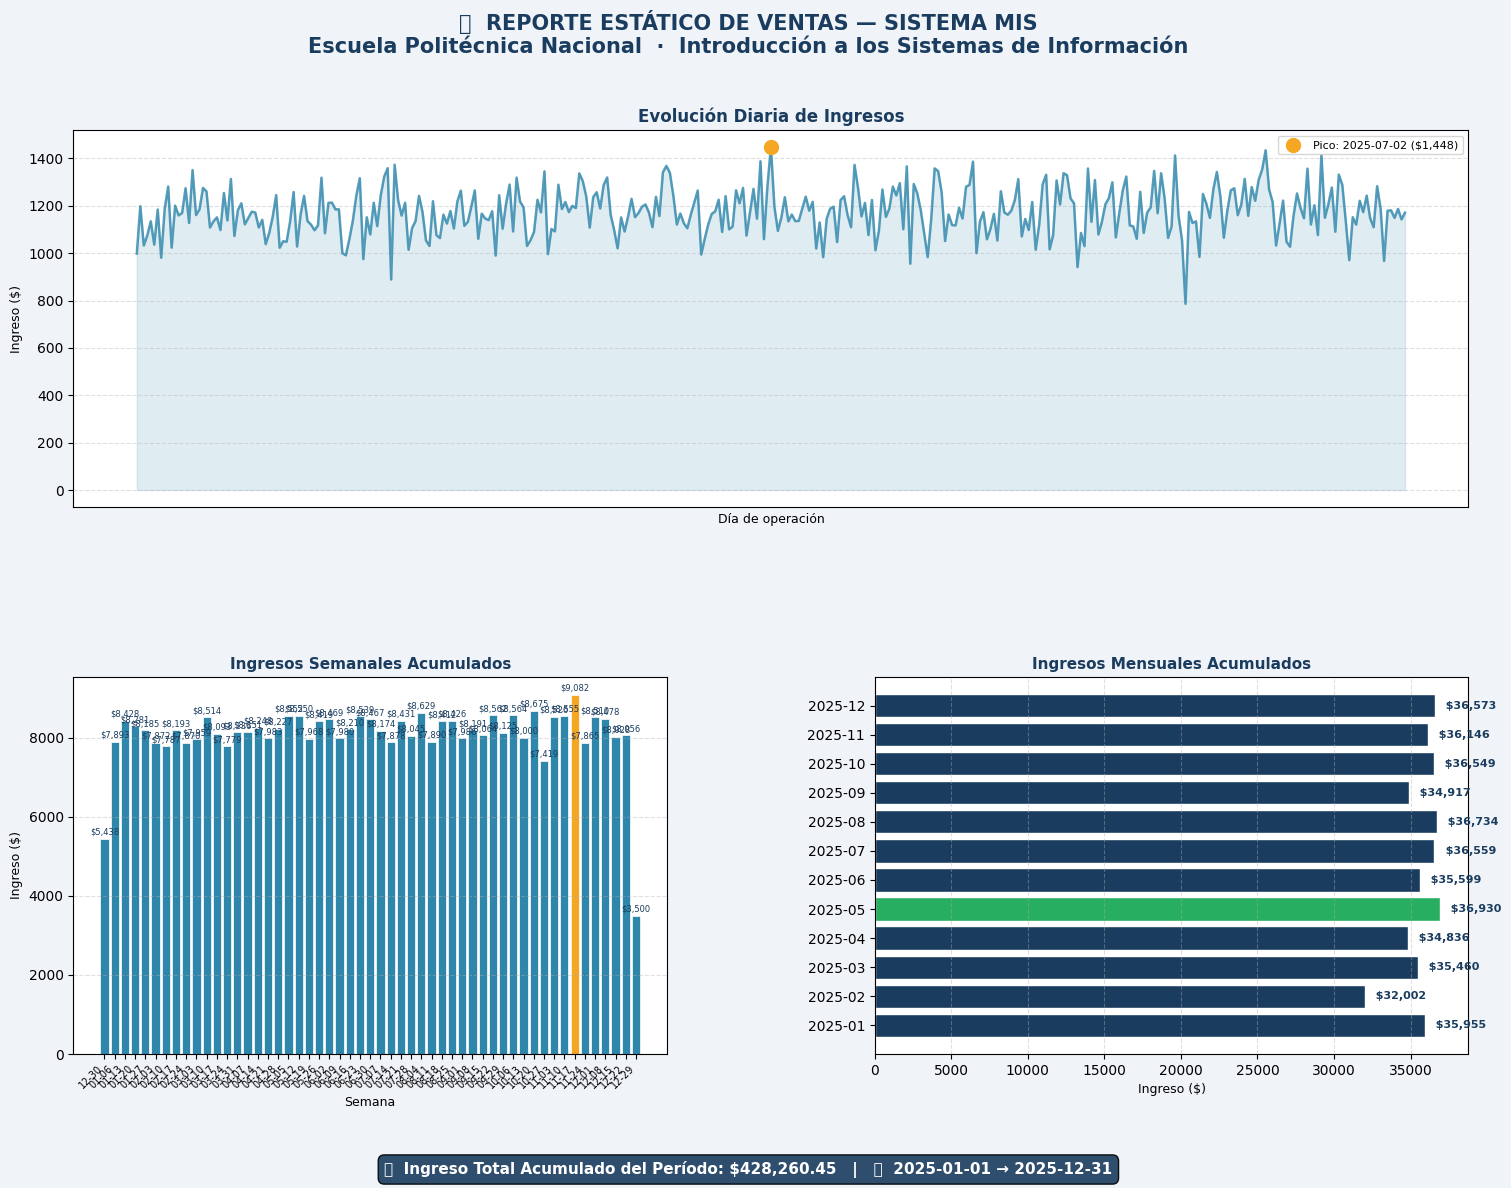

📁 Guardado en /content/reporte_estatico.png


In [4]:
# ─── SECCIÓN A: REPORTE ESTÁTICO ─────────────────────────────────────────────
ventas_dia = facturas.groupby('Dia')['Ingreso'].sum().reset_index()
ventas_sem = facturas.groupby('Semana')['Ingreso'].sum().reset_index()
ventas_mes = facturas.groupby('Mes')['Ingreso'].sum().reset_index()

fig = plt.figure(figsize=(18, 12), facecolor=FONDO)
fig.suptitle(
    'REPORTE ESTÁTICO DE VENTAS — SISTEMA MIS\n'
    'Escuela Politécnica Nacional  ·  Introducción a los Sistemas de Información',
    fontsize=15, fontweight='bold', color=COLOR_PRIMARIO, y=0.98
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Ventas diarias
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('white')
ax1.plot(range(len(ventas_dia)), ventas_dia['Ingreso'],
         color=COLOR_SECUNDARIO, linewidth=1.8, alpha=0.8)
ax1.fill_between(range(len(ventas_dia)), ventas_dia['Ingreso'],
                 alpha=0.15, color=COLOR_SECUNDARIO)
idx_max = ventas_dia['Ingreso'].idxmax()
ax1.scatter(idx_max, ventas_dia.loc[idx_max,'Ingreso'],
            color=COLOR_ACENTO, zorder=5, s=100,
            label=f"Pico: {ventas_dia.loc[idx_max,'Dia']} (${ventas_dia.loc[idx_max,'Ingreso']:,.0f})")
ax1.set_title('Evolución Diaria de Ingresos', fontsize=12, fontweight='bold', color=COLOR_PRIMARIO)
ax1.set_xlabel('Día de operación', fontsize=9)
ax1.set_ylabel('Ingreso ($)', fontsize=9)
ax1.legend(fontsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Panel 2: Ventas semanales
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('white')
colores_sem = [COLOR_ACENTO if v == ventas_sem['Ingreso'].max()
               else COLOR_SECUNDARIO for v in ventas_sem['Ingreso']]
bars = ax2.bar(range(len(ventas_sem)), ventas_sem['Ingreso'],
               color=colores_sem, edgecolor='white', linewidth=0.5)
ax2.set_title('Ingresos Semanales Acumulados', fontsize=11, fontweight='bold', color=COLOR_PRIMARIO)
ax2.set_xlabel('Semana', fontsize=9)
ax2.set_ylabel('Ingreso ($)', fontsize=9)
ax2.set_xticks(range(len(ventas_sem)))
ax2.set_xticklabels([s.split('/')[0][-5:] for s in ventas_sem['Semana']], rotation=45, ha='right', fontsize=7)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"${bar.get_height():,.0f}", ha='center', va='bottom', fontsize=6, color=COLOR_PRIMARIO)

# Panel 3: Ventas mensuales
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('white')
colores_mes = [COLOR_POSITIVO if v == ventas_mes['Ingreso'].max()
               else COLOR_PRIMARIO for v in ventas_mes['Ingreso']]
ax3.barh(ventas_mes['Mes'], ventas_mes['Ingreso'], color=colores_mes, edgecolor='white')
ax3.set_title('Ingresos Mensuales Acumulados', fontsize=11, fontweight='bold', color=COLOR_PRIMARIO)
ax3.set_xlabel('Ingreso ($)', fontsize=9)
ax3.grid(axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(ventas_mes['Ingreso']):
    ax3.text(v + 200, i, f'  ${v:,.0f}', va='center', fontsize=8, color=COLOR_PRIMARIO, fontweight='bold')

total = facturas['Ingreso'].sum()
fig.text(0.5, 0.01,
         f"💰  Ingreso Total Acumulado del Período: ${total:,.2f}   |   "
         f"📅  {ventas_dia['Dia'].min()} → {ventas_dia['Dia'].max()}",
         ha='center', fontsize=11, fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.4', facecolor=COLOR_PRIMARIO, alpha=0.9))

plt.savefig('/content/reporte_estatico.png', dpi=120, bbox_inches='tight', facecolor=FONDO)
plt.show()
print("📁 Guardado en /content/reporte_estatico.png")

In [15]:
# CÁLCULO DE KPIs

# KPI 1
kpi1 = facturas.groupby('Nombre_Cliente')['Hora'].count().reset_index()
kpi1.columns = ['Cliente', 'Visitas']
kpi1 = kpi1.sort_values('Visitas', ascending=False)
UMBRAL_BONO = 18

# KPI 2
kpi2 = df.groupby('Categoria')['Ingreso'].mean().reset_index()
kpi2.columns = ['Categoria', 'Promedio_Consumo']
kpi2 = kpi2.sort_values('Promedio_Consumo', ascending=False)

# KPI 3
kpi3 = df.groupby('Categoria')['Ingreso'].sum().reset_index()
total_ingresos = kpi3['Ingreso'].sum()
kpi3['Participacion'] = (kpi3['Ingreso'] / total_ingresos) * 100
kpi3 = kpi3.sort_values('Participacion', ascending=False)

# KPI 4
kpi4 = (facturas.groupby(['Nombre_Cliente','Fecha','Tipo_Cliente'])['Ingreso']
        .sum().reset_index())
kpi4_res = kpi4.groupby('Tipo_Cliente')['Ingreso'].mean().reset_index()
kpi4_res.columns = ['Tipo_Cliente', 'Ticket_Promedio']

# KPI 5
kpi5 = facturas.groupby('Producto')['Cantidad'].sum().reset_index()
kpi5.columns = ['Producto', 'Unidades_Vendidas']
kpi5 = kpi5.sort_values('Unidades_Vendidas', ascending=False).head(10)

# KPI 6
kpi6 = facturas.groupby('Hora_int')['Ingreso'].sum().reset_index()
kpi6.columns = ['Hora', 'Ingreso_Total']

# KPI 7
compras_mes = facturas.groupby(['Nombre_Cliente','Mes']).size().reset_index(name='n')
meses_por_cliente = compras_mes.groupby('Nombre_Cliente')['Mes'].nunique()
total_clientes = meses_por_cliente.shape[0]
clientes_recurrentes = (meses_por_cliente >= 2).sum()
tasa_retencion = clientes_recurrentes / total_clientes * 100

# KPI 8
ventas_cat = df.groupby('Categoria')['Cantidad'].sum().reset_index()
stock_cat  = (productos.groupby('Categoria')['Stock'].sum().reset_index()
              .rename(columns={'Stock':'Stock_Total'}))
kpi8 = ventas_cat.merge(stock_cat, on='Categoria', how='left')
kpi8['Rotacion'] = kpi8['Cantidad'] / kpi8['Stock_Total']
kpi8 = kpi8.sort_values('Rotacion', ascending=False)

# Función base compartida
def _base_fig(titulo_kpi, descripcion):
    fig = plt.figure(figsize=(14, 7), facecolor=FONDO)
    fig.text(0.0, 0.96, '  🏫 EPN · Ciencia de Datos e IA  |  Sistema MIS — Dashboard Gerencial',
             fontsize=8.5, color='white', va='top',
             bbox=dict(boxstyle='square,pad=0.0', facecolor=COLOR_PRIMARIO, alpha=1.0))
    fig.text(0.5, 0.91, titulo_kpi, ha='center', fontsize=15,
             fontweight='bold', color=COLOR_PRIMARIO)
    fig.text(0.5, 0.87, descripcion, ha='center', fontsize=9.5,
             color='#555555', style='italic')
    return fig

print("KPIs calculados y función base lista.")

KPIs calculados y función base lista.


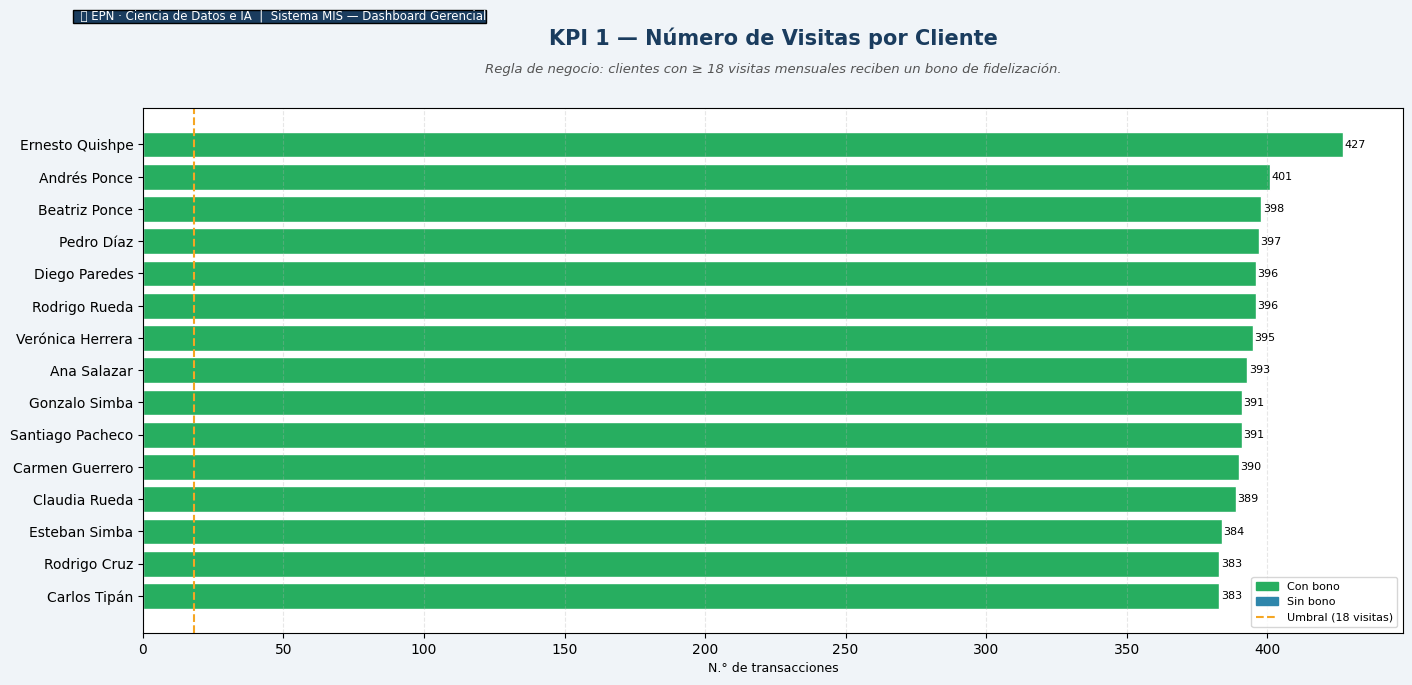

In [16]:
top = kpi1.head(15).sort_values('Visitas')
colores = [COLOR_POSITIVO if v >= UMBRAL_BONO else COLOR_SECUNDARIO for v in top['Visitas']]

fig = _base_fig(
    'KPI 1 — Número de Visitas por Cliente',
    'Regla de negocio: clientes con ≥ 18 visitas mensuales reciben un bono de fidelización.'
)
ax = fig.add_axes([0.05, 0.07, 0.90, 0.75])
ax.set_facecolor('white')
bars = ax.barh(top['Cliente'], top['Visitas'], color=colores, edgecolor='white')
ax.axvline(UMBRAL_BONO, color=COLOR_ACENTO, linestyle='--', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.0f}', va='center', fontsize=8)
ax.set_xlabel('N.° de transacciones', fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.3)
parche1 = mpatches.Patch(color=COLOR_POSITIVO, label='Con bono')
parche2 = mpatches.Patch(color=COLOR_SECUNDARIO, label='Sin bono')
linea   = plt.Line2D([0],[0], color=COLOR_ACENTO, linestyle='--', label=f'Umbral ({UMBRAL_BONO} visitas)')
ax.legend(handles=[parche1, parche2, linea], fontsize=8)
plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

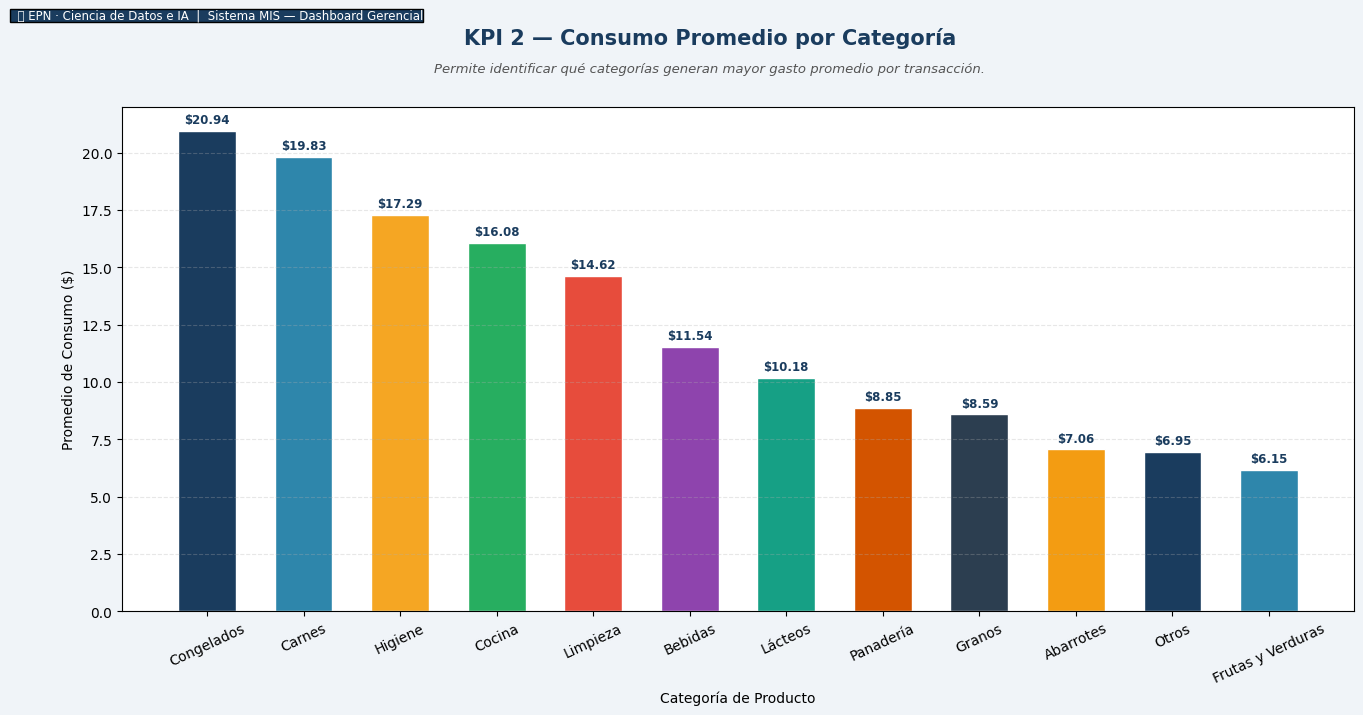

In [17]:
fig = _base_fig(
    'KPI 2 — Consumo Promedio por Categoría',
    'Permite identificar qué categorías generan mayor gasto promedio por transacción.'
)
ax = fig.add_axes([0.08, 0.10, 0.88, 0.72])
ax.set_facecolor('white')
cat_ord = kpi2.sort_values('Promedio_Consumo', ascending=False)
bars = ax.bar(cat_ord['Categoria'], cat_ord['Promedio_Consumo'],
              color=COLORES_CAT[:len(cat_ord)], edgecolor='white', width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'${bar.get_height():.2f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=COLOR_PRIMARIO)
ax.set_ylabel('Promedio de Consumo ($)', fontsize=10)
ax.set_xlabel('Categoría de Producto', fontsize=10)
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

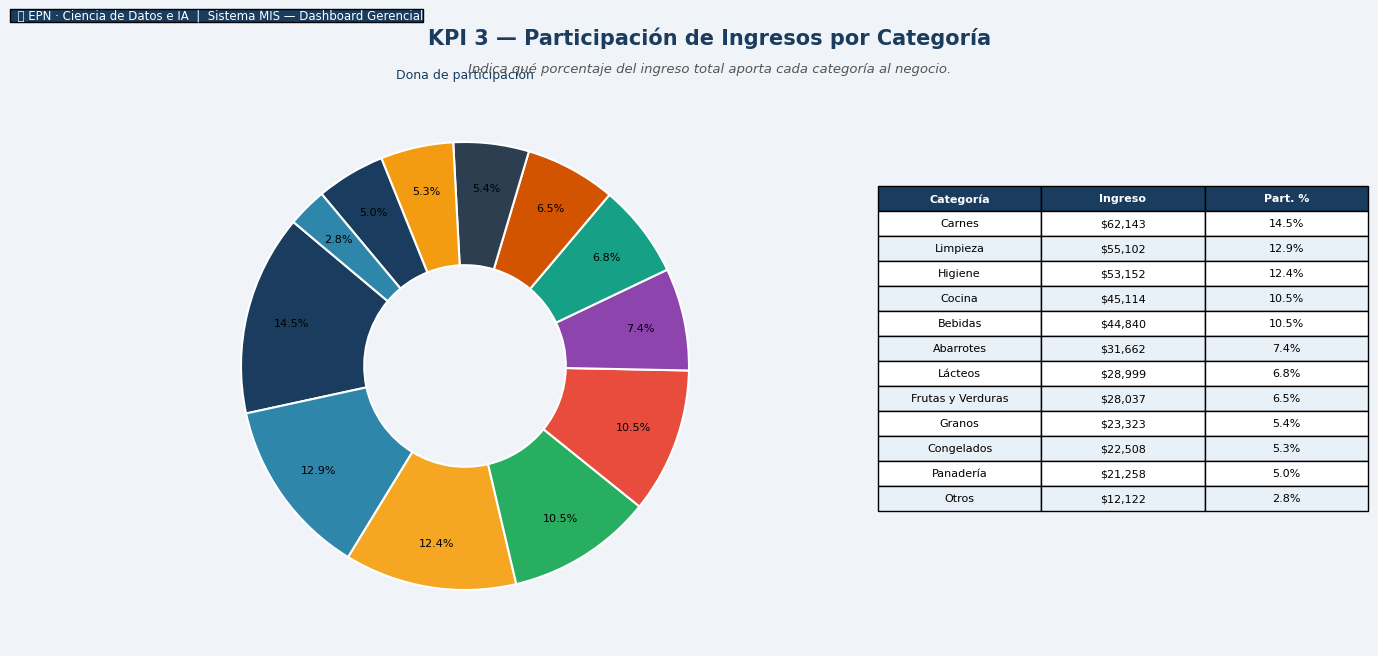

In [18]:
fig = _base_fig(
    'KPI 3 — Participación de Ingresos por Categoría',
    'Indica qué porcentaje del ingreso total aporta cada categoría al negocio.'
)
ax = fig.add_axes([0.05, 0.05, 0.55, 0.80])
wedges, texts, autotexts = ax.pie(
    kpi3['Participacion'], labels=None, autopct='%1.1f%%',
    colors=COLORES_CAT[:len(kpi3)], startangle=140, pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Dona de participación', fontsize=9, color=COLOR_PRIMARIO)

ax2 = fig.add_axes([0.62, 0.10, 0.35, 0.75])
ax2.axis('off')
tabla_data = [[row['Categoria'], f"${row['Ingreso']:,.0f}", f"{row['Participacion']:.1f}%"]
              for _, row in kpi3.iterrows()]
tabla = ax2.table(cellText=tabla_data, colLabels=['Categoría', 'Ingreso', 'Part. %'],
                  cellLoc='center', loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1, 1.5)
for (r, c), cell in tabla.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLOR_PRIMARIO)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E8F0F8')
plt.show()

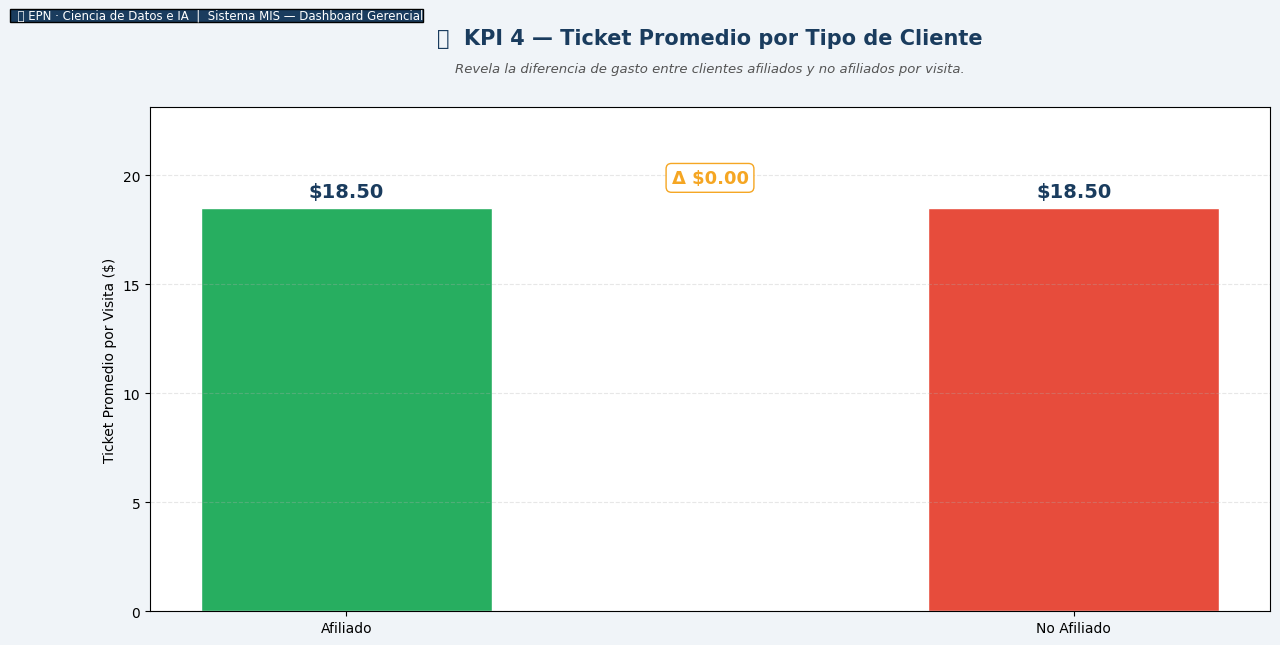

In [9]:
fig = _base_fig(
    'KPI 4 — Ticket Promedio por Tipo de Cliente',
    'Revela la diferencia de gasto entre clientes afiliados y no afiliados por visita.'
)
ax = fig.add_axes([0.10, 0.10, 0.80, 0.72])
ax.set_facecolor('white')
colores_tipo = [COLOR_POSITIVO, COLOR_NEGATIVO][:len(kpi4_res)]
bars = ax.bar(kpi4_res['Tipo_Cliente'], kpi4_res['Ticket_Promedio'],
              color=colores_tipo, width=0.4, edgecolor='white')
for bar, val in zip(bars, kpi4_res['Ticket_Promedio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val:.2f}', ha='center', fontsize=14, fontweight='bold', color=COLOR_PRIMARIO)
ax.set_ylabel('Ticket Promedio por Visita ($)', fontsize=10)
ax.set_ylim(0, kpi4_res['Ticket_Promedio'].max() * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.3)
if len(kpi4_res) == 2:
    dif = abs(kpi4_res['Ticket_Promedio'].iloc[0] - kpi4_res['Ticket_Promedio'].iloc[1])
    ax.annotate(f'Δ ${dif:.2f}', xy=(0.5, 0.85), xycoords='axes fraction', ha='center',
                fontsize=13, color=COLOR_ACENTO, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_ACENTO))
plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

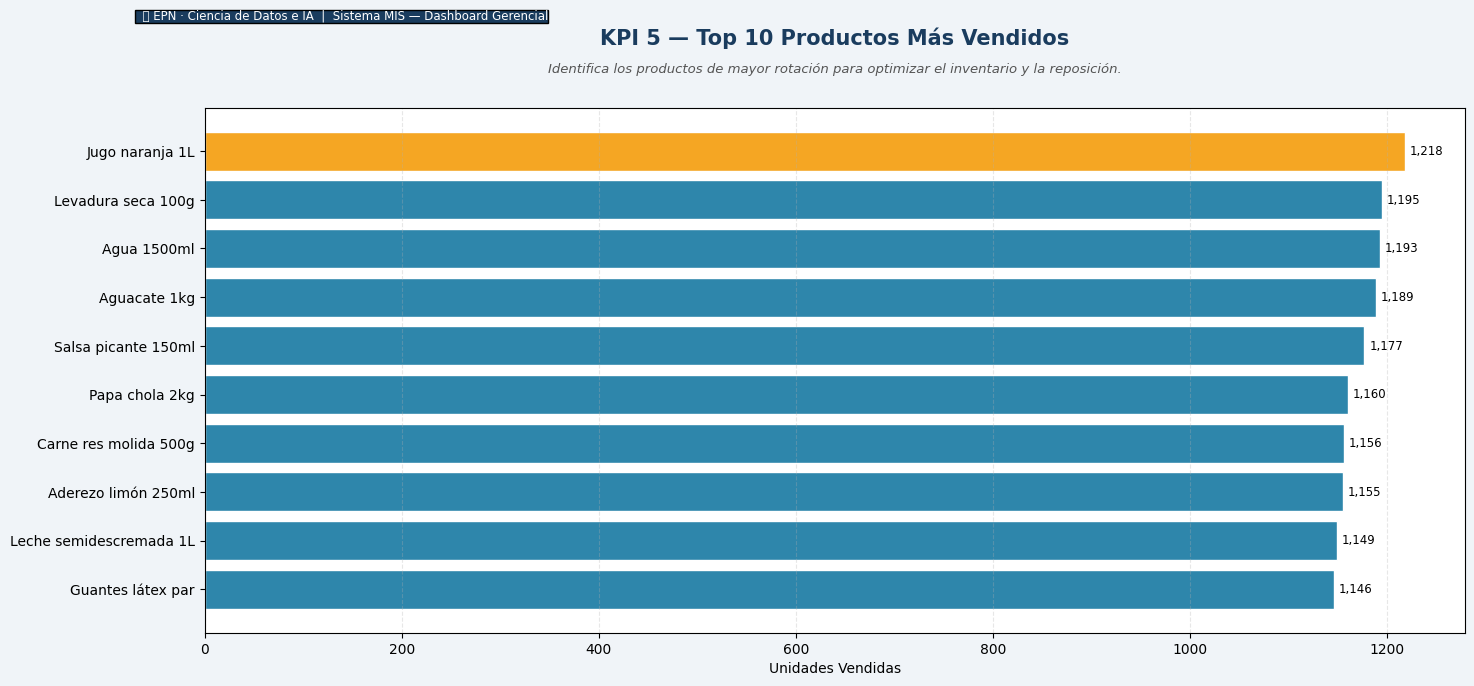

In [24]:
fig = _base_fig(
    'KPI 5 — Top 10 Productos Más Vendidos',
    'Identifica los productos de mayor rotación para optimizar el inventario y la reposición.'
)
ax = fig.add_axes([0.05, 0.07, 0.90, 0.75])
ax.set_facecolor('white')
top10 = kpi5.sort_values('Unidades_Vendidas')
colores = [COLOR_ACENTO if i == len(top10)-1 else COLOR_SECUNDARIO for i in range(len(top10))]
bars = ax.barh(top10['Producto'], top10['Unidades_Vendidas'], color=colores, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Unidades Vendidas', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

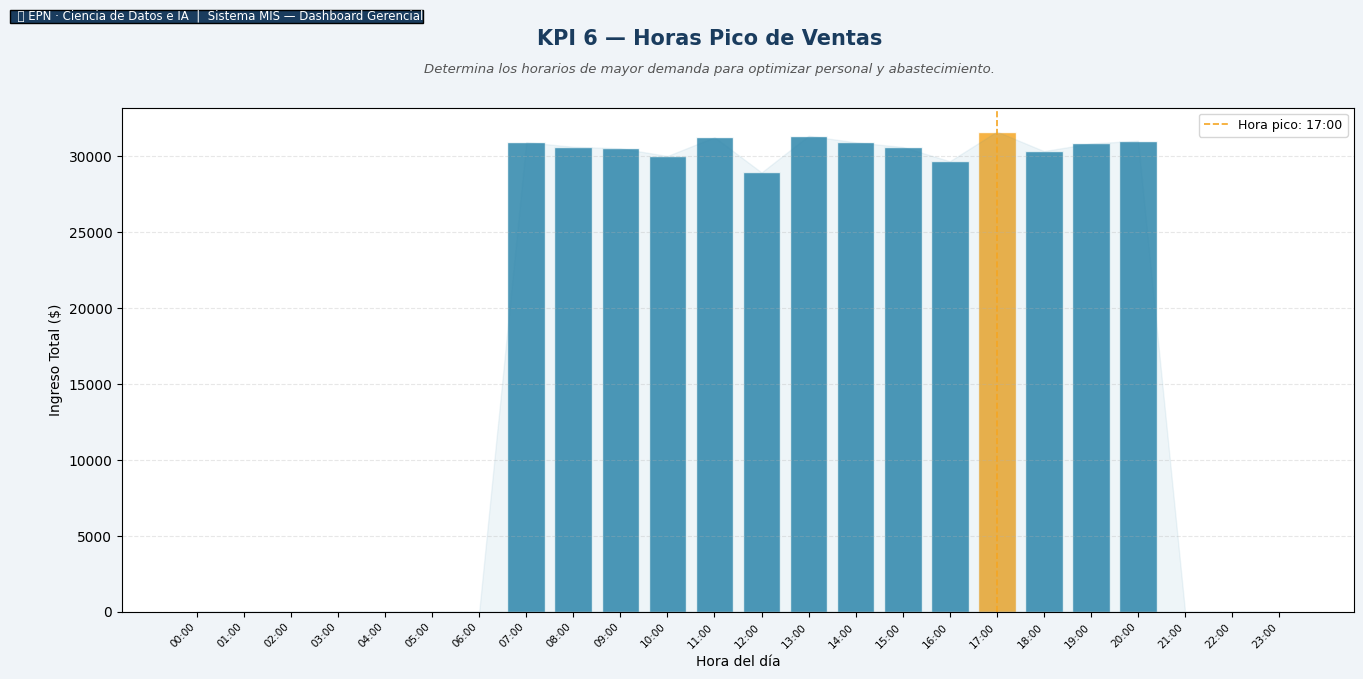

In [23]:
fig = _base_fig(
    'KPI 6 — Horas Pico de Ventas',
    'Determina los horarios de mayor demanda para optimizar personal y abastecimiento.'
)
ax = fig.add_axes([0.08, 0.10, 0.88, 0.72])
ax.set_facecolor('white')
horas_completas = pd.DataFrame({'Hora': range(24)})
kpi6_full = horas_completas.merge(kpi6, on='Hora', how='left').fillna(0)
hora_pico = kpi6_full.loc[kpi6_full['Ingreso_Total'].idxmax(), 'Hora']
colores_h = [COLOR_ACENTO if h == hora_pico else COLOR_SECUNDARIO for h in kpi6_full['Hora']]
ax.bar(kpi6_full['Hora'], kpi6_full['Ingreso_Total'], color=colores_h, alpha=0.85, edgecolor='white')
ax.fill_between(kpi6_full['Hora'], kpi6_full['Ingreso_Total'], alpha=0.08, color=COLOR_SECUNDARIO)
ax.set_xlabel('Hora del día', fontsize=10)
ax.set_ylabel('Ingreso Total ($)', fontsize=10)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=7.5)
ax.axvline(hora_pico, color=COLOR_ACENTO, linestyle='--', linewidth=1.2,
           label=f'Hora pico: {hora_pico:02d}:00')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

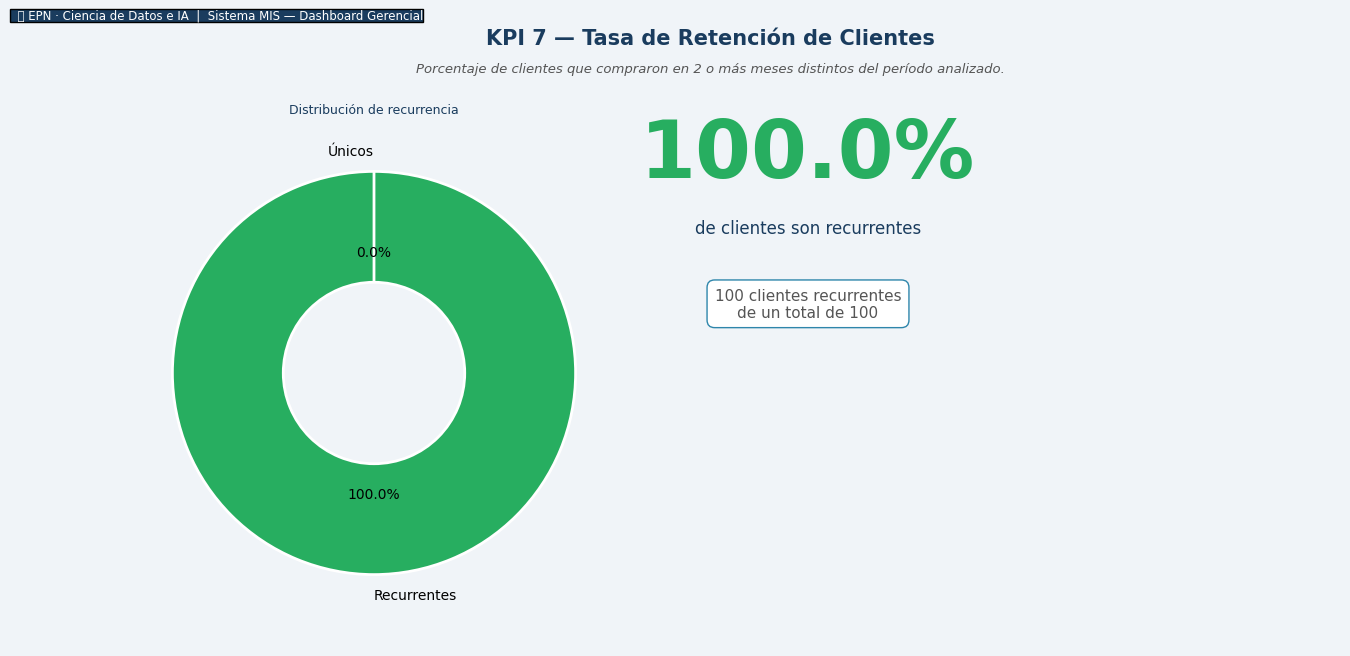

In [22]:
fig = _base_fig(
    'KPI 7 — Tasa de Retención de Clientes',
    'Porcentaje de clientes que compraron en 2 o más meses distintos del período analizado.'
)
ax = fig.add_axes([0.05, 0.05, 0.90, 0.80])
ax.axis('off')

ax_dona = fig.add_axes([0.05, 0.08, 0.42, 0.72])
retenidos    = int(clientes_recurrentes)
no_retenidos = int(total_clientes - clientes_recurrentes)
ax_dona.pie(
    [retenidos, no_retenidos], labels=['Recurrentes', 'Únicos'],
    colors=[COLOR_POSITIVO, COLOR_NEUTRO], autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
ax_dona.set_title('Distribución de recurrencia', fontsize=9, color=COLOR_PRIMARIO)

fig.text(0.57, 0.72, f'{tasa_retencion:.1f}%', ha='center', fontsize=58,
         fontweight='bold',
         color=COLOR_POSITIVO if tasa_retencion > 50 else COLOR_NEGATIVO)
fig.text(0.57, 0.64, 'de clientes son recurrentes', ha='center', fontsize=12, color=COLOR_PRIMARIO)
fig.text(0.57, 0.52, f'{retenidos} clientes recurrentes\nde un total de {total_clientes}',
         ha='center', fontsize=11, color='#555555',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLOR_SECUNDARIO))
plt.show()

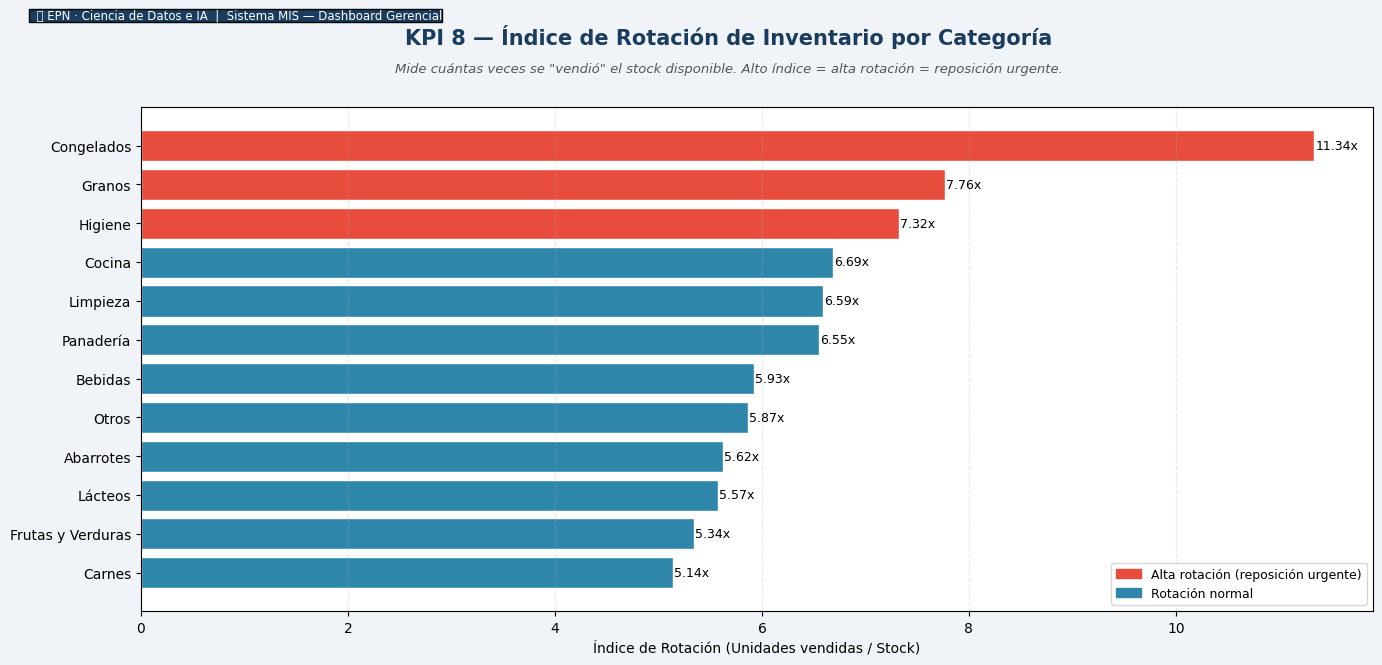

In [21]:
fig = _base_fig(
    'KPI 8 — Índice de Rotación de Inventario por Categoría',
    'Mide cuántas veces se "vendió" el stock disponible. Alto índice = alta rotación = reposición urgente.'
)
ax = fig.add_axes([0.08, 0.10, 0.88, 0.72])
ax.set_facecolor('white')
kpi8_ord = kpi8.sort_values('Rotacion', ascending=True)
colores_r = [COLOR_NEGATIVO if r > kpi8_ord['Rotacion'].quantile(0.75)
             else COLOR_SECUNDARIO for r in kpi8_ord['Rotacion']]
bars = ax.barh(kpi8_ord['Categoria'], kpi8_ord['Rotacion'], color=colores_r, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}x', va='center', fontsize=9)
ax.set_xlabel('Índice de Rotación (Unidades vendidas / Stock)', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.3)
parche_a = mpatches.Patch(color=COLOR_NEGATIVO, label='Alta rotación (reposición urgente)')
parche_b = mpatches.Patch(color=COLOR_SECUNDARIO, label='Rotación normal')
ax.legend(handles=[parche_a, parche_b], fontsize=9)
plt.tight_layout(rect=[0,0,1,0.88])
plt.show()